In [1]:
!pip install openpyxl

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import TensorDataset, DataLoader



In [3]:
# =========================================================
# 1. LOAD + CLEAN
# =========================================================
co = pd.read_excel(r"D:\Master Of Data Science And AI\Capstone\model\data\dataset3\co_sensor.xlsx")
cng = pd.read_excel(r"D:\Master Of Data Science And AI\Capstone\model\data\dataset3\cng_sensor.xlsx")
lpg = pd.read_excel(r"D:\Master Of Data Science And AI\Capstone\model\data\dataset3\lpg_sensor.xlsx")
smoke = pd.read_excel(r"D:\Master Of Data Science And AI\Capstone\model\data\dataset3\smoke_sensor.xlsx")
flame = pd.read_excel(r"D:\Master Of Data Science And AI\Capstone\model\data\dataset3\flame_sensor.xlsx")

df3 = pd.DataFrame({
    "CO": pd.to_numeric(co["data_value"], errors="coerce"),
    "CNG": pd.to_numeric(cng["data_value"], errors="coerce"),
    "LPG": pd.to_numeric(lpg["data_value"], errors="coerce"),
    "Smoke": pd.to_numeric(smoke["data_value"], errors="coerce"),
    "Flame": pd.to_numeric(flame["data_value"], errors="coerce"),
})

df3 = df3.replace([np.inf, -np.inf], np.nan).ffill().bfill().fillna(0)

In [4]:
# =========================================================
# 2. CREATE SENSOR-RULE LABELS 
# =========================================================

q = df3.quantile([0.90, 0.95, 0.98])

thr_co    = q.loc[0.95, "CO"]
thr_smoke = q.loc[0.95, "Smoke"]
thr_flame = q.loc[0.95, "Flame"]
thr_cng   = q.loc[0.95, "CNG"]
thr_lpg   = q.loc[0.95, "LPG"]

print("Chosen rule thresholds:")
print({
    "CO": thr_co,
    "Smoke": thr_smoke,
    "Flame": thr_flame,
    "CNG": thr_cng,
    "LPG": thr_lpg
})


sensor_event = (
    (df3["Flame"] >= thr_flame) |
    ((df3["Smoke"] >= thr_smoke) & ((df3["CO"] >= thr_co) | (df3["CNG"] >= thr_cng) | (df3["LPG"] >= thr_lpg))) |
    (((df3["CO"] >= thr_co).astype(int) +
      (df3["CNG"] >= thr_cng).astype(int) +
      (df3["LPG"] >= thr_lpg).astype(int) +
      (df3["Smoke"] >= thr_smoke).astype(int) +
      (df3["Flame"] >= thr_flame).astype(int)) >= 2)
).astype(int)

df3["EventLabel"] = sensor_event

print("\nEvent label counts:")
print(df3["EventLabel"].value_counts())

Chosen rule thresholds:
{'CO': np.float64(0.9623747500000001), 'Smoke': np.float64(17.30433), 'Flame': np.float64(0.9599982499999999), 'CNG': np.float64(22.71324), 'LPG': np.float64(25.3964)}

Event label counts:
EventLabel
0    1864
1     172
Name: count, dtype: int64


In [5]:
# =========================================================
# 3. SCALE FEATURES
# =========================================================
feature_cols = ["CO", "CNG", "LPG", "Smoke", "Flame"]

scaler3 = StandardScaler()
X3 = scaler3.fit_transform(df3[feature_cols])

In [6]:
# =========================================================
# 4. WINDOWING WITH LABEL ALIGNMENT
# =========================================================
window_size = 60

X3_windows = []
y3_windows = []
label_windows = []

for i in range(len(X3) - window_size):
    X3_windows.append(X3[i:i+window_size])
    y3_windows.append(X3[i+window_size])
    label_windows.append(df3["EventLabel"].iloc[i+window_size])

X3_windows = np.array(X3_windows, dtype=np.float32)
y3_windows = np.array(y3_windows, dtype=np.float32)
label_windows = np.array(label_windows, dtype=np.int32)

print("Window shapes:", X3_windows.shape, y3_windows.shape, label_windows.shape)
print("Window label counts:", np.unique(label_windows, return_counts=True))

Window shapes: (1976, 60, 5) (1976, 5) (1976,)
Window label counts: (array([0, 1], dtype=int32), array([1807,  169]))


In [7]:
# =========================================================
# 5. TRAIN / TEST SPLIT
# =========================================================
from sklearn.model_selection import train_test_split


X_train, X_temp, y_train, y_temp, label_train, label_temp = train_test_split(
    X3_windows, y3_windows, label_windows,
    test_size=0.3,
    random_state=42,
    stratify=label_windows
)


X_val, X_test, y_val, y_test, label_val, label_test = train_test_split(
    X_temp, y_temp, label_temp,
    test_size=0.5,
    random_state=42,
    stratify=label_temp
)

In [8]:
# =========================================================
# 6. TCN MODEL
# =========================================================
class Chomp1d(nn.Module):
    def __init__(self, chomp_size):
        super().__init__()
        self.chomp_size = chomp_size

    def forward(self, x):
        return x[:, :, :-self.chomp_size]


class TemporalBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation, dropout=0.2):
        super().__init__()
        padding = (kernel_size - 1) * dilation

        self.conv1 = nn.Conv1d(
            in_channels, out_channels, kernel_size,
            padding=padding, dilation=dilation
        )
        self.chomp1 = Chomp1d(padding)
        self.relu1 = nn.ReLU()
        self.dropout1 = nn.Dropout(dropout)

        self.conv2 = nn.Conv1d(
            out_channels, out_channels, kernel_size,
            padding=padding, dilation=dilation
        )
        self.chomp2 = Chomp1d(padding)
        self.relu2 = nn.ReLU()
        self.dropout2 = nn.Dropout(dropout)

        self.net = nn.Sequential(
            self.conv1, self.chomp1, self.relu1, self.dropout1,
            self.conv2, self.chomp2, self.relu2, self.dropout2
        )

        self.downsample = nn.Conv1d(in_channels, out_channels, 1) if in_channels != out_channels else None
        self.relu = nn.ReLU()

    def forward(self, x):
        out = self.net(x)
        res = x if self.downsample is None else self.downsample(x)
        return self.relu(out + res)


class TCNForecaster(nn.Module):
    def __init__(self, input_size, channels=[32, 64], kernel_size=3, dropout=0.2, output_size=5):
        super().__init__()
        layers = []
        in_channels = input_size

        for i, out_channels in enumerate(channels):
            dilation = 2 ** i
            layers.append(
                TemporalBlock(in_channels, out_channels, kernel_size, dilation, dropout)
            )
            in_channels = out_channels

        self.tcn = nn.Sequential(*layers)
        self.fc = nn.Linear(channels[-1], output_size)

    def forward(self, x):
        x = x.transpose(1, 2)
        y = self.tcn(x)
        y = y[:, :, -1]
        y = self.fc(y)
        return y

device = torch.device("cpu")

model3 = TCNForecaster(
    input_size=5,
    channels=[32, 64],
    kernel_size=3,
    dropout=0.2,
    output_size=5
).to(device)

train_dataset3 = TensorDataset(
    torch.tensor(X_train, dtype=torch.float32),
    torch.tensor(y_train, dtype=torch.float32)
)
train_loader3 = DataLoader(train_dataset3, batch_size=32, shuffle=True)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model3.parameters(), lr=1e-4)

epochs = 10
train_losses = []

for epoch in range(epochs):
    model3.train()
    total_loss = 0.0

    for xb, yb in train_loader3:
        xb = xb.to(device)
        yb = yb.to(device)

        optimizer.zero_grad()
        pred = model3(xb)
        loss = criterion(pred, yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model3.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(train_loader3)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}/{epochs} Loss {avg_loss:.6f}")
    

Epoch 1/10 Loss 0.979260
Epoch 2/10 Loss 0.841853
Epoch 3/10 Loss 0.687676
Epoch 4/10 Loss 0.547725
Epoch 5/10 Loss 0.511878
Epoch 6/10 Loss 0.489613
Epoch 7/10 Loss 0.487667
Epoch 8/10 Loss 0.482698
Epoch 9/10 Loss 0.478251
Epoch 10/10 Loss 0.472999


In [9]:
# =========================================================
# 7. TEST RESIDUALS + RISK
# =========================================================
model3.eval()
with torch.no_grad():
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32).to(device)

    y_pred = model3(X_test_tensor)
    residuals = torch.abs(y_pred - y_test_tensor).cpu().numpy()
    residual_score = residuals.mean(axis=1)

risk = (residual_score - residual_score.min()) / (
    residual_score.max() - residual_score.min() + 1e-8
)


In [10]:
# =========================================================
# 8. PERSISTENCE FILTER
# =========================================================
def persistence_filter(risk, threshold=0.5, min_len=2):
    out = np.zeros(len(risk), dtype=int)
    count = 0
    for i, r in enumerate(risk):
        if r >= threshold:
            count += 1
        else:
            count = 0
        if count >= min_len:
            out[i] = 1
    return out


candidate_thresholds = np.linspace(0.30, 0.80, 11)
candidate_minlens = [1, 2, 3, 4, 5]

search_rows = []
for t in candidate_thresholds:
    for m in candidate_minlens:
        pred_alarm = persistence_filter(risk, threshold=float(t), min_len=int(m))
        report = classification_report(label_test, pred_alarm, output_dict=True, zero_division=0)
        search_rows.append({
            "threshold": t,
            "min_len": m,
            "precision_1": report["1"]["precision"],
            "recall_1": report["1"]["recall"],
            "f1_1": report["1"]["f1-score"]
        })

df_search = pd.DataFrame(search_rows).sort_values(["f1_1", "recall_1"], ascending=False)
print(df_search.head(10))

best_threshold = float(df_search.iloc[0]["threshold"])
best_min_len = int(df_search.iloc[0]["min_len"])

final_alarm = persistence_filter(risk, threshold=best_threshold, min_len=best_min_len)

print("\nBest threshold:", best_threshold)
print("Best min_len:", best_min_len)

    threshold  min_len  precision_1  recall_1      f1_1
40       0.70        1     0.500000  0.423077  0.458333
45       0.75        1     0.526316  0.384615  0.444444
30       0.60        1     0.368421  0.538462  0.437500
35       0.65        1     0.400000  0.461538  0.428571
20       0.50        1     0.265823  0.807692  0.400000
25       0.55        1     0.285714  0.615385  0.390244
26       0.55        2     0.538462  0.269231  0.358974
21       0.50        2     0.360000  0.346154  0.352941
11       0.40        2     0.250000  0.538462  0.341463
15       0.45        1     0.205882  0.807692  0.328125

Best threshold: 0.7
Best min_len: 1


In [11]:
# =========================================================
# 9. EVALUATION
# =========================================================
print("\nClassification report:")
print(classification_report(label_test, final_alarm, zero_division=0))

print("Confusion matrix:")
print(confusion_matrix(label_test, final_alarm))


Classification report:
              precision    recall  f1-score   support

           0       0.95      0.96      0.95       271
           1       0.50      0.42      0.46        26

    accuracy                           0.91       297
   macro avg       0.72      0.69      0.71       297
weighted avg       0.91      0.91      0.91       297

Confusion matrix:
[[260  11]
 [ 15  11]]


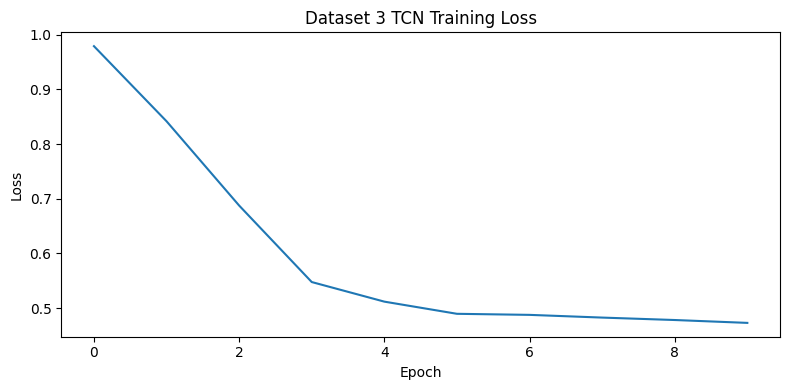

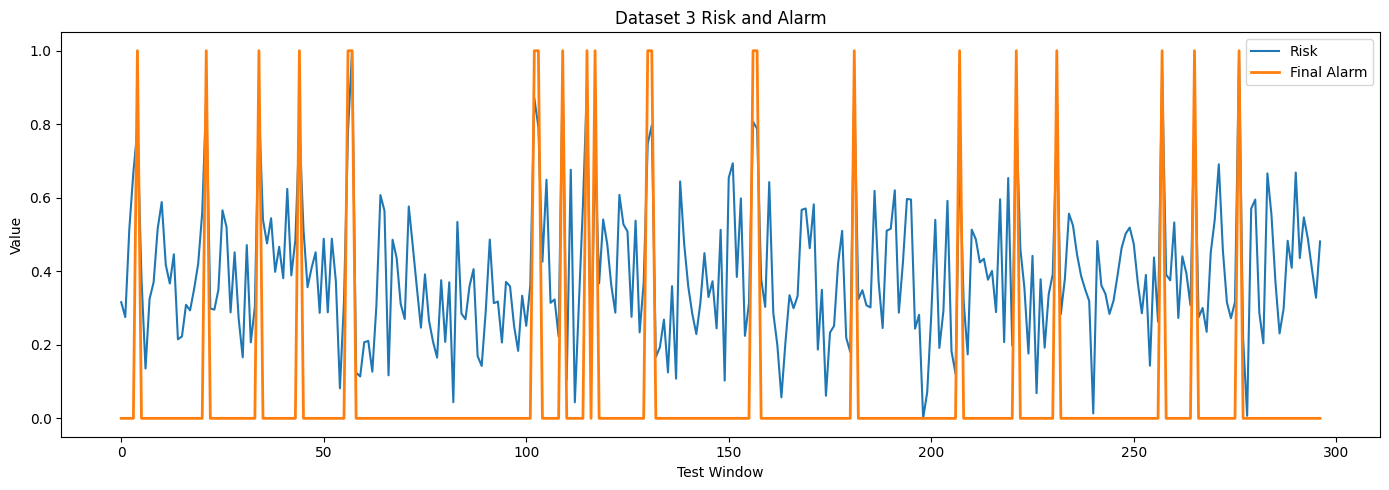

In [12]:
# =========================================================
# 10. PLOTS
# =========================================================
plt.figure(figsize=(8, 4))
plt.plot(train_losses)
plt.title("Dataset 3 TCN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.tight_layout()
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(risk, label="Risk")
plt.plot(final_alarm, label="Final Alarm", linewidth=2)
plt.title("Dataset 3 Risk and Alarm")
plt.xlabel("Test Window")
plt.ylabel("Value")
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
# =========================================================
# 11. SAVE
# =========================================================
os.makedirs("results", exist_ok=True)
os.makedirs("models", exist_ok=True)

df3_result = pd.DataFrame({
    "ResidualScore": residual_score,
    "Risk": risk,
    "TrueLabel": label_test,
    "FinalAlarm": final_alarm
})
df3_result.to_csv("results/dataset3_final_results.csv", index=False)

torch.save(model3.state_dict(), "models/tcn_dataset3_forecaster.pt")
with open("models/scaler_dataset3.pkl", "wb") as f:
    pickle.dump(scaler3, f)

df_search.to_csv("results/dataset3_threshold_search.csv", index=False)

print("Dataset 3 final results saved.")

Dataset 3 final results saved.


In [14]:
import pandas as pd
import numpy as np

feature_names3 = ["CO", "CNG", "LPG", "Smoke", "Flame"]

def build_residual_feature_df(residuals, residual_score, feature_names):
    df_feat = pd.DataFrame()

    df_feat["residual_mean"] = residuals.mean(axis=1)
    df_feat["residual_max"] = residuals.max(axis=1)
    df_feat["residual_std"] = residuals.std(axis=1)
    df_feat["residual_min"] = residuals.min(axis=1)
    df_feat["residual_range"] = residuals.max(axis=1) - residuals.min(axis=1)
    df_feat["residual_score"] = residual_score

    for i, name in enumerate(feature_names):
        df_feat[f"{name}_residual"] = residuals[:, i]

    sorted_res = np.sort(residuals, axis=1)
    df_feat["top1_residual"] = sorted_res[:, -1]
    df_feat["top2_residual"] = sorted_res[:, -2]

    return df_feat



In [15]:
model3.eval()

with torch.no_grad():
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.float32)

    y_train_pred = model3(X_train_tensor)
    residuals_train = torch.abs(y_train_pred - y_train_tensor).numpy()
    residual_score_train = residuals_train.mean(axis=1)

with torch.no_grad():
    X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
    y_test_tensor = torch.tensor(y_test, dtype=torch.float32)

    y_test_pred = model3(X_test_tensor)
    residuals_test = torch.abs(y_test_pred - y_test_tensor).numpy()
    residual_score_test = residuals_test.mean(axis=1)

with torch.no_grad():
    X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
    y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

    y_val_pred = model3(X_val_tensor)
    residuals_val = torch.abs(y_val_pred - y_val_tensor).numpy()
    residual_score_val = residuals_val.mean(axis=1)
risk_min = residual_score_train.min()
risk_max = residual_score_train.max()

risk_val = (residual_score_val - risk_min) / (risk_max - risk_min + 1e-8)

feat_val = build_residual_feature_df(residuals_val, residual_score_val, feature_names3)
feat_val["risk_tcn"] = risk_val

In [16]:

risk_train = (residual_score_train - risk_min) / (risk_max - risk_min + 1e-8)
risk_test  = (residual_score_test  - risk_min) / (risk_max - risk_min + 1e-8)
risk_val   = (residual_score_val   - risk_min) / (risk_max - risk_min + 1e-8)

In [17]:
def build_residual_feature_df(residuals, residual_score, feature_names):
    import pandas as pd
    import numpy as np

    df_feat = pd.DataFrame()

    df_feat["residual_mean"] = residuals.mean(axis=1)
    df_feat["residual_max"] = residuals.max(axis=1)
    df_feat["residual_std"] = residuals.std(axis=1)
    df_feat["residual_min"] = residuals.min(axis=1)
    df_feat["residual_range"] = residuals.max(axis=1) - residuals.min(axis=1)
    df_feat["residual_score"] = residual_score

    for i, name in enumerate(feature_names):
        df_feat[f"{name}_residual"] = residuals[:, i]

    sorted_res = np.sort(residuals, axis=1)
    df_feat["top1_residual"] = sorted_res[:, -1]
    df_feat["top2_residual"] = sorted_res[:, -2]

    return df_feat

In [18]:
feature_names3 = ["CO", "CNG", "LPG", "Smoke", "Flame"]

feat_train = build_residual_feature_df(residuals_train, residual_score_train, feature_names3)
feat_test = build_residual_feature_df(residuals_test, residual_score_test, feature_names3)

feat_train["risk_tcn"] = risk_train
feat_test["risk_tcn"] = risk_test

In [19]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

normal_idx_train = (label_train == 0)

scaler_iso3 = StandardScaler()
feat_train_scaled = scaler_iso3.fit_transform(feat_train)
feat_test_scaled = scaler_iso3.transform(feat_test)

feat_train_normal_scaled = feat_train_scaled[normal_idx_train]

iso3 = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42
)

iso3.fit(feat_train_normal_scaled)

iso_train_raw = iso3.score_samples(feat_train_scaled)
iso_test_raw = iso3.score_samples(feat_test_scaled)

iso_train = (iso_train_raw.max() - iso_train_raw) / (iso_train_raw.max() - iso_train_raw.min() + 1e-8)
iso_test = (iso_train_raw.max() - iso_test_raw) / (iso_train_raw.max() - iso_train_raw.min() + 1e-8)
feat_val_scaled = scaler_iso3.transform(feat_val)

iso_val_raw = iso3.score_samples(feat_val_scaled)
iso_val = (iso_train_raw.max() - iso_val_raw) / (iso_train_raw.max() - iso_train_raw.min() + 1e-8)

feat_val["iso_score"] = iso_val

feat_train["iso_score"] = iso_train
feat_test["iso_score"] = iso_test

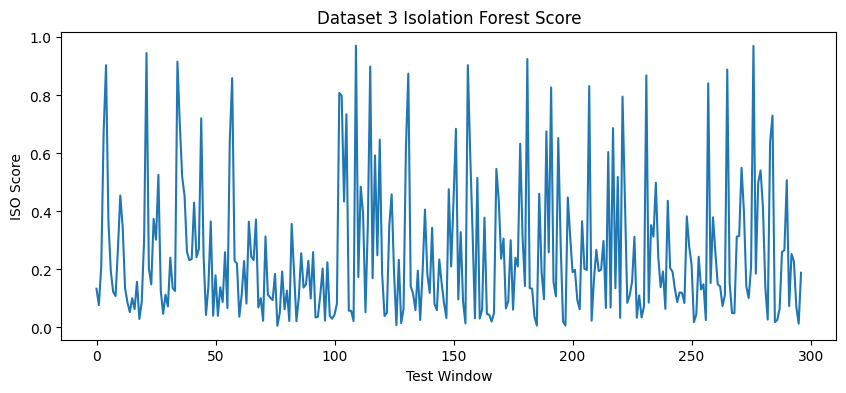

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(iso_test)
plt.title("Dataset 3 Isolation Forest Score")
plt.xlabel("Test Window")
plt.ylabel("ISO Score")
plt.show()

In [21]:
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

X_train_ae = torch.tensor(feat_train_scaled[normal_idx_train], dtype=torch.float32)
X_test_ae = torch.tensor(feat_test_scaled, dtype=torch.float32)
X_train_all_ae = torch.tensor(feat_train_scaled, dtype=torch.float32)

ae_loader3 = DataLoader(
    TensorDataset(X_train_ae, X_train_ae),
    batch_size=32,
    shuffle=True
)

class AE3(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32), nn.ReLU(),
            nn.Linear(32, 16), nn.ReLU(),
            nn.Linear(16, 8)
        )
        self.decoder = nn.Sequential(
            nn.Linear(8, 16), nn.ReLU(),
            nn.Linear(16, 32), nn.ReLU(),
            nn.Linear(32, input_dim)
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

device = torch.device("cpu")
ae3 = AE3(input_dim=feat_train_scaled.shape[1]).to(device)
criterion_ae = nn.MSELoss()
optimizer_ae = torch.optim.Adam(ae3.parameters(), lr=1e-3)

ae_losses = []

for epoch in range(30):
    ae3.train()
    total_loss = 0.0

    for xb, _ in ae_loader3:
        xb = xb.to(device)

        optimizer_ae.zero_grad()
        recon = ae3(xb)
        loss = criterion_ae(recon, xb)
        loss.backward()
        optimizer_ae.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(ae_loader3)
    ae_losses.append(avg_loss)
    print(f"AE Epoch {epoch+1}/30 | Loss: {avg_loss:.6f}")

AE Epoch 1/30 | Loss: 0.697666
AE Epoch 2/30 | Loss: 0.479145
AE Epoch 3/30 | Loss: 0.363000
AE Epoch 4/30 | Loss: 0.307730
AE Epoch 5/30 | Loss: 0.267788
AE Epoch 6/30 | Loss: 0.257342
AE Epoch 7/30 | Loss: 0.245578
AE Epoch 8/30 | Loss: 0.220073
AE Epoch 9/30 | Loss: 0.200222
AE Epoch 10/30 | Loss: 0.189469
AE Epoch 11/30 | Loss: 0.171837
AE Epoch 12/30 | Loss: 0.140806
AE Epoch 13/30 | Loss: 0.113999
AE Epoch 14/30 | Loss: 0.090002
AE Epoch 15/30 | Loss: 0.075455
AE Epoch 16/30 | Loss: 0.069007
AE Epoch 17/30 | Loss: 0.065343
AE Epoch 18/30 | Loss: 0.062101
AE Epoch 19/30 | Loss: 0.060339
AE Epoch 20/30 | Loss: 0.058699
AE Epoch 21/30 | Loss: 0.057552
AE Epoch 22/30 | Loss: 0.056294
AE Epoch 23/30 | Loss: 0.054947
AE Epoch 24/30 | Loss: 0.052897
AE Epoch 25/30 | Loss: 0.051347
AE Epoch 26/30 | Loss: 0.050229
AE Epoch 27/30 | Loss: 0.048022
AE Epoch 28/30 | Loss: 0.044172
AE Epoch 29/30 | Loss: 0.040419
AE Epoch 30/30 | Loss: 0.036088


In [22]:
def get_ae_score(model, X_tensor, device):
    model.eval()
    with torch.no_grad():
        X_tensor = X_tensor.to(device)
        recon = model(X_tensor)
        err = torch.mean((X_tensor - recon) ** 2, dim=1).cpu().numpy()
    return err
X_val_ae = torch.tensor(feat_val_scaled, dtype=torch.float32)
ae_train_raw = get_ae_score(ae3, X_train_all_ae, device)

ae_min = ae_train_raw.min()
ae_max = ae_train_raw.max()

ae_val_raw = get_ae_score(ae3, X_val_ae, device)
ae_val = (ae_val_raw - ae_min) / (ae_max - ae_min + 1e-8)

feat_val["ae_score"] = ae_val

ae_train_raw = get_ae_score(ae3, X_train_all_ae, device)
ae_test_raw = get_ae_score(ae3, X_test_ae, device)

ae_min = ae_train_raw.min()
ae_max = ae_train_raw.max()

ae_train = (ae_train_raw - ae_min) / (ae_max - ae_min + 1e-8)
ae_test = (ae_test_raw - ae_min) / (ae_max - ae_min + 1e-8)

feat_train["ae_score"] = ae_train
feat_test["ae_score"] = ae_test

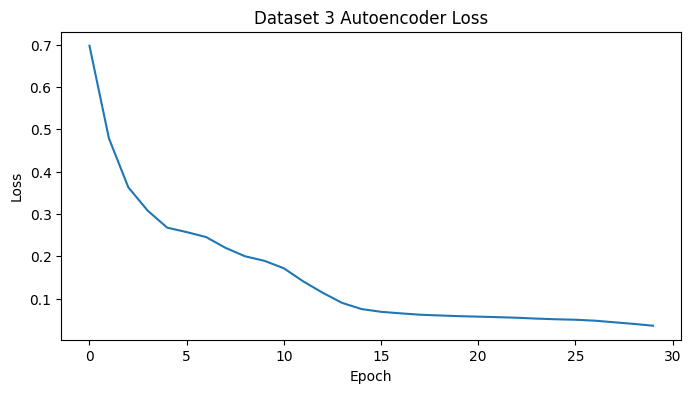

In [23]:
plt.figure(figsize=(8,4))
plt.plot(ae_losses)
plt.title("Dataset 3 Autoencoder Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [24]:
def rolling_mean_diff(x, short_win=5, long_win=30):
    x = pd.Series(x)
    short_ma = x.rolling(short_win, min_periods=1).mean()
    long_ma = x.rolling(long_win, min_periods=1).mean()
    return (short_ma - long_ma).abs().values

feat_train["drift_score"] = rolling_mean_diff(feat_train["risk_tcn"].values, 5, 30)
feat_test["drift_score"] = rolling_mean_diff(feat_test["risk_tcn"].values, 5, 30)
feat_val["drift_score"] = rolling_mean_diff(feat_val["risk_tcn"].values, 5, 30)
drift_threshold = np.percentile(feat_train["drift_score"], 90)
feat_val["drift_flag"] = (feat_val["drift_score"] > drift_threshold).astype(int)



feat_train["drift_flag"] = (feat_train["drift_score"] > drift_threshold).astype(int)
feat_test["drift_flag"] = (feat_test["drift_score"] > drift_threshold).astype(int)

In [25]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
import pandas as pd
import numpy as np

fusion_train = feat_train.copy()
fusion_val = feat_val.copy()
fusion_test = feat_test.copy()

fusion_train["label"] = label_train.astype(int)
fusion_val["label"] = label_val.astype(int)
fusion_test["label"] = label_test.astype(int)

X_train_fusion = fusion_train.drop(columns=["label"])
y_train_fusion = fusion_train["label"]

X_val_fusion = fusion_val.drop(columns=["label"])
y_val_fusion = fusion_val["label"]

X_test_fusion = fusion_test.drop(columns=["label"])
y_test_fusion = fusion_test["label"]

scale_pos_weight = (y_train_fusion == 0).sum() / max((y_train_fusion == 1).sum(), 1)

xgb3 = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric="logloss",
    random_state=42
)


xgb3.fit(X_train_fusion, y_train_fusion)


test_probs = xgb3.predict_proba(X_test_fusion)[:, 1]
test_pred = (test_probs >= 0.5).astype(int)

print("Fusion model test report:")
print(classification_report(y_test_fusion, test_pred, zero_division=0))
print(confusion_matrix(y_test_fusion, test_pred))


val_probs = xgb3.predict_proba(X_val_fusion)[:, 1]

search_rows = []
for t in np.linspace(0.30, 0.80, 11):
    for m in [1, 2, 3, 4]:
        pred_alarm = persistence_filter(val_probs, threshold=float(t), min_len=int(m))
        search_rows.append({
            "threshold": float(t),
            "min_len": int(m),
            "precision": precision_score(y_val_fusion, pred_alarm, zero_division=0),
            "recall": recall_score(y_val_fusion, pred_alarm, zero_division=0),
            "f1": f1_score(y_val_fusion, pred_alarm, zero_division=0)
        })

df_search = pd.DataFrame(search_rows).sort_values(["f1", "recall"], ascending=False)
print(df_search.head(10))


best_t = float(df_search.iloc[0]["threshold"])
best_m = int(df_search.iloc[0]["min_len"])


print("Best threshold:", best_t)
print("Best min_len:", best_m)


final_alarm = persistence_filter(test_probs, threshold=best_t, min_len=best_m)

print("Final alarm test report:")
print(classification_report(y_test_fusion, final_alarm, zero_division=0))
print(confusion_matrix(y_test_fusion, final_alarm))

Fusion model test report:
              precision    recall  f1-score   support

           0       0.97      0.94      0.96       271
           1       0.55      0.69      0.61        26

    accuracy                           0.92       297
   macro avg       0.76      0.82      0.78       297
weighted avg       0.93      0.92      0.93       297

[[256  15]
 [  8  18]]
    threshold  min_len  precision  recall        f1
40       0.80        1   0.809524    0.68  0.739130
36       0.75        1   0.739130    0.68  0.708333
32       0.70        1   0.708333    0.68  0.693878
24       0.60        1   0.666667    0.72  0.692308
28       0.65        1   0.680000    0.68  0.680000
20       0.55        1   0.620690    0.72  0.666667
16       0.50        1   0.600000    0.72  0.654545
12       0.45        1   0.562500    0.72  0.631579
8        0.40        1   0.529412    0.72  0.610169
4        0.35        1   0.514286    0.72  0.600000
Best threshold: 0.8
Best min_len: 1
Final alarm test

In [26]:
def persistence_filter(risk, threshold=0.5, min_len=2):
    out = np.zeros(len(risk), dtype=int)
    count = 0
    for i, r in enumerate(risk):
        if r >= threshold:
            count += 1
        else:
            count = 0
        if count >= min_len:
            out[i] = 1
    return out

In [27]:
val_probs = xgb3.predict_proba(X_val_fusion)[:, 1]

search_rows = []

for t in np.linspace(0.30, 0.80, 11):
    for m in [1, 2, 3, 4]:

        pred_alarm = persistence_filter(val_probs, threshold=t, min_len=m)

        search_rows.append({
            "threshold": t,
            "min_len": m,
            "f1": f1_score(y_val_fusion, pred_alarm),
            "precision": precision_score(y_val_fusion, pred_alarm),
            "recall": recall_score(y_val_fusion, pred_alarm)
        })

df_search = pd.DataFrame(search_rows).sort_values("f1", ascending=False)

best_t = df_search.iloc[0]["threshold"]
best_m = df_search.iloc[0]["min_len"]
final_alarm3 = persistence_filter(test_probs, threshold=best_t, min_len=best_m)

C:\Users\Yasitha\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Yasitha\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Yasitha\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result

In [28]:
test_probs = xgb3.predict_proba(X_test_fusion)[:, 1]

final_alarm = persistence_filter(test_probs, threshold=best_t, min_len=best_m)

print(classification_report(y_test_fusion, final_alarm))

              precision    recall  f1-score   support

           0       0.97      0.98      0.97       271
           1       0.77      0.65      0.71        26

    accuracy                           0.95       297
   macro avg       0.87      0.82      0.84       297
weighted avg       0.95      0.95      0.95       297



In [29]:
best_row3 = df_search.iloc[0]
best_threshold3 = float(best_row3["threshold"])
best_min_len3 = int(best_row3["min_len"])

final_alarm3 = persistence_filter(test_probs, threshold=best_threshold3, min_len=best_min_len3)

print("Best threshold:", best_threshold3)
print("Best min_len:", best_min_len3)

print(classification_report(y_test_fusion, final_alarm3, zero_division=0))
print(confusion_matrix(y_test_fusion, final_alarm3))

Best threshold: 0.8
Best min_len: 1
              precision    recall  f1-score   support

           0       0.97      0.98      0.97       271
           1       0.77      0.65      0.71        26

    accuracy                           0.95       297
   macro avg       0.87      0.82      0.84       297
weighted avg       0.95      0.95      0.95       297

[[266   5]
 [  9  17]]


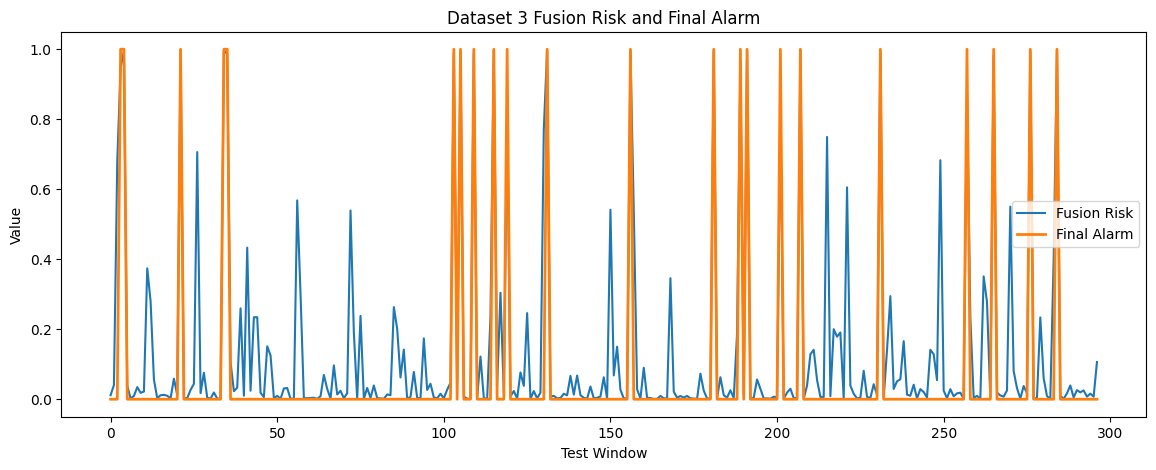

In [30]:
plt.figure(figsize=(14,5))
plt.plot(test_probs, label="Fusion Risk")
plt.plot(final_alarm3, label="Final Alarm", linewidth=2)
plt.title("Dataset 3 Fusion Risk and Final Alarm")
plt.xlabel("Test Window")
plt.ylabel("Value")
plt.legend()
plt.show()

In [31]:
import os
import pickle

os.makedirs("results", exist_ok=True)
os.makedirs("models/dataset3", exist_ok=True)

df3_final = pd.DataFrame({
    "ResidualScore": residual_score_test,
    "RiskTCN": risk_test,
    "ISOScore": feat_test["iso_score"].values,
    "AEScore": feat_test["ae_score"].values,
    "DriftScore": feat_test["drift_score"].values,
    "DriftFlag": feat_test["drift_flag"].values,
    "FusionRisk": test_probs,
    "TrueLabel": y_test_fusion.values,
    "FinalAlarm": final_alarm3
})

df3_final.to_csv("results/dataset3_full_pipeline.csv", index=False)
df_search.to_csv("results/dataset3_threshold_search.csv", index=False)

torch.save(model3.state_dict(), "models/dataset3/tcn_dataset3_forecaster.pt")
torch.save(ae3.state_dict(), "models/dataset3/ae_dataset3.pth")
xgb3.save_model("models/dataset3/xgb_dataset3.json")

with open("models/dataset3/scaler_dataset3.pkl", "wb") as f:
    pickle.dump(scaler3, f)

with open("models/dataset3/scaler_iso3.pkl", "wb") as f:
    pickle.dump(scaler_iso3, f)

print("Dataset 3 full pipeline saved successfully.")

Dataset 3 full pipeline saved successfully.


In [32]:
# ==========================================
# FIXED BASELINE EVALUATION (DATASET 3)
# ==========================================

import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("\n==============================")
print(" BASELINE MODEL COMPARISON ")
print("==============================\n")

rows = []

# ------------------------------------------
# A. TCN-only baseline
# ------------------------------------------
# true labels
true_label_test = label_test.astype(int)

# TCN risk
tcn_pred = (risk_test >= 0.5).astype(int)

tcn_acc = accuracy_score(true_label_test, tcn_pred)
tcn_prec = precision_score(true_label_test, tcn_pred, zero_division=0)
tcn_rec = recall_score(true_label_test, tcn_pred, zero_division=0)
tcn_f1 = f1_score(true_label_test, tcn_pred, zero_division=0)

print("----- TCN ONLY -----")
print("Accuracy :", tcn_acc)
print("Precision:", tcn_prec)
print("Recall   :", tcn_rec)
print("F1 Score :", tcn_f1)
print()

rows.append({
    "Model": "TCN-only",
    "Accuracy": tcn_acc,
    "Precision": tcn_prec,
    "Recall": tcn_rec,
    "F1": tcn_f1
})

# ------------------------------------------
# B. ISO-only baseline
# ------------------------------------------
if "iso_score" in feat_test.columns:
    iso_pred = (feat_test["iso_score"].values >= 0.5).astype(int)

    iso_acc = accuracy_score(true_label_test, iso_pred)
    iso_prec = precision_score(true_label_test, iso_pred, zero_division=0)
    iso_rec = recall_score(true_label_test, iso_pred, zero_division=0)
    iso_f1 = f1_score(true_label_test, iso_pred, zero_division=0)

    print("----- ISOLATION FOREST ONLY -----")
    print("Accuracy :", iso_acc)
    print("Precision:", iso_prec)
    print("Recall   :", iso_rec)
    print("F1 Score :", iso_f1)
    print()

    rows.append({
        "Model": "Isolation Forest",
        "Accuracy": iso_acc,
        "Precision": iso_prec,
        "Recall": iso_rec,
        "F1": iso_f1
    })
else:
    print("ISO baseline skipped: iso_score not found.\n")

# ------------------------------------------
# C. Hybrid Fusion baseline
# ------------------------------------------
true_alarm_test = y_test_fusion.astype(int)

fusion_pred = final_alarm3.astype(int)

fusion_acc = accuracy_score(true_alarm_test, fusion_pred)
fusion_prec = precision_score(true_alarm_test, fusion_pred, zero_division=0)
fusion_rec = recall_score(true_alarm_test, fusion_pred, zero_division=0)
fusion_f1 = f1_score(true_alarm_test, fusion_pred, zero_division=0)

print("----- HYBRID FUSION -----")
print("Accuracy :", fusion_acc)
print("Precision:", fusion_prec)
print("Recall   :", fusion_rec)
print("F1 Score :", fusion_f1)
print()

rows.append({
    "Model": "Hybrid Fusion",
    "Accuracy": fusion_acc,
    "Precision": fusion_prec,
    "Recall": fusion_rec,
    "F1": fusion_f1
})

# ------------------------------------------
# D. Summary table
# ------------------------------------------
baseline_df = pd.DataFrame(rows)
print("----- SUMMARY TABLE -----")
print(baseline_df)

baseline_df.to_csv("results/dataset3_baseline_comparison.csv", index=False)
print("\nSaved: results/dataset3_baseline_comparison.csv")


 BASELINE MODEL COMPARISON 

----- TCN ONLY -----
Accuracy : 0.8653198653198653
Precision: 0.3409090909090909
Recall   : 0.5769230769230769
F1 Score : 0.42857142857142855

----- ISOLATION FOREST ONLY -----
Accuracy : 0.8821548821548821
Precision: 0.3953488372093023
Recall   : 0.6538461538461539
F1 Score : 0.4927536231884058

----- HYBRID FUSION -----
Accuracy : 0.9528619528619529
Precision: 0.7727272727272727
Recall   : 0.6538461538461539
F1 Score : 0.7083333333333334

----- SUMMARY TABLE -----
              Model  Accuracy  Precision    Recall        F1
0          TCN-only  0.865320   0.340909  0.576923  0.428571
1  Isolation Forest  0.882155   0.395349  0.653846  0.492754
2     Hybrid Fusion  0.952862   0.772727  0.653846  0.708333

Saved: results/dataset3_baseline_comparison.csv
